# Neural Gadget Controller Demos
This notebook is designed as a easy einterface to call the functions that we have defined

In [1]:
%load_ext autoreload
%autoreload 2

import pandas as pd
import numpy as np

import torch.optim as optim
import torch.nn as nn
import torch

from scipy.stats import pearsonr
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, MinMaxScaler

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

import matplotlib.pyplot as plt
import seaborn as sns

from data_loader import load_participants_info, load_event_descriptions, load_behavioral_data, preprocess_data, preprocess_data_stress, preprocess_data_duration

Pipeline still not super robust, set seed for reproduciability

In [2]:
import random
import numpy as np
import torch

def set_seed(seed):
    """Sets seed for reproducibility across random, NumPy, and PyTorch."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed) 
    print(f"Seed set to {seed} for reproducibility!")

set_seed(12345678)

Seed set to 12345678 for reproducibility!


# Data Preparation
Let's prepare some data first to fit our model. We are specifically using ["Locus coeruleus activity strengthens prioritized memories under arousal"](https://openneuro.org/datasets/ds002011/versions/1.0.0) dataset fror now.

In [3]:
DATASET_PATH = "data"
participants_df = load_participants_info(DATASET_PATH)
load_event_descriptions(DATASET_PATH)

df_behavior = load_behavioral_data(DATASET_PATH, "01")
for idx in range(2,11):
    sample_participant = f"0{idx}"
    df = load_behavioral_data(DATASET_PATH, sample_participant)
    df_behavior = pd.concat([df, df_behavior], ignore_index=True)

Let's preprocess our data first

In [4]:
X, Y, X_tensor, Y_tensor, scaler_X, scaler_Y, df_clean = preprocess_data(df_behavior)
X_stress = preprocess_data_stress(df_behavior, condition="AROUSING")
X_neurtal = preprocess_data_stress(df_behavior, condition="NEUTRAL")
X_long = preprocess_data_duration(df_behavior, duration="long")
X_short = preprocess_data_duration(df_behavior, duration="short")

X Shape: torch.Size([1699, 7]), Y Shape: torch.Size([1699])
Y Min: -1.0, Y Max: 1.0


In [5]:
X_train, X_test, Y_train, Y_test = train_test_split(X_tensor, Y_tensor, test_size=0.2, random_state=42)

X_stress_train, X_stress_test = train_test_split(X_stress, test_size=0.2, random_state=42)
X_neutral_train, X_neutral_test = train_test_split(X_neurtal, test_size=0.2, random_state=42)
X_long_train, X_long_test = train_test_split(X_long, test_size=0.2, random_state=42)
X_short_train, X_short_test = train_test_split(X_short, test_size=0.2, random_state=42)

# Training

In [6]:
from train import (train_feed_forward_nn,
                   train_vanilla_lstm,
                   train_vanilla_lc_model,
                   train_lstm_lc_model,
                   train_ff_controller,
                   train_ff_uncertain_controller
                   )
from analysis.evaluation import evaluate_model

## Fully Connected Neural Network

To illustrate our idea, we want to train 2 models from math and computer science, which is our vanilla feed forward networks and an recurrent networks.

Epoch 0, Loss: 0.06351486593484879
Epoch 100, Loss: 0.04626790061593056
Epoch 200, Loss: 0.04494001716375351
Epoch 300, Loss: 0.04389322176575661
Epoch 400, Loss: 0.04305620491504669
Epoch 500, Loss: 0.04302782192826271
Epoch 600, Loss: 0.04152817651629448
Epoch 700, Loss: 0.040543872863054276
Epoch 800, Loss: 0.04007464274764061
Epoch 900, Loss: 0.03982623293995857
Epoch 1000, Loss: 0.03921101242303848
Epoch 1100, Loss: 0.038908347487449646
Epoch 1200, Loss: 0.03942841291427612
Epoch 1300, Loss: 0.0388057716190815
Epoch 1400, Loss: 0.039009541273117065
Epoch 1500, Loss: 0.040016211569309235
Epoch 1600, Loss: 0.03840828686952591
Epoch 1700, Loss: 0.039640143513679504
Epoch 1800, Loss: 0.03975236043334007
Epoch 1900, Loss: 0.03780664876103401
Training complete!
Evaluating Model: FeedForwardNN


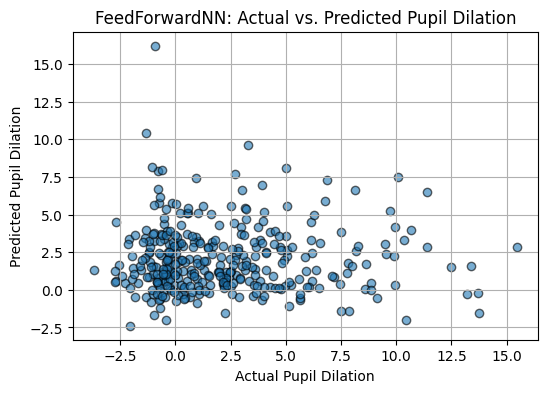

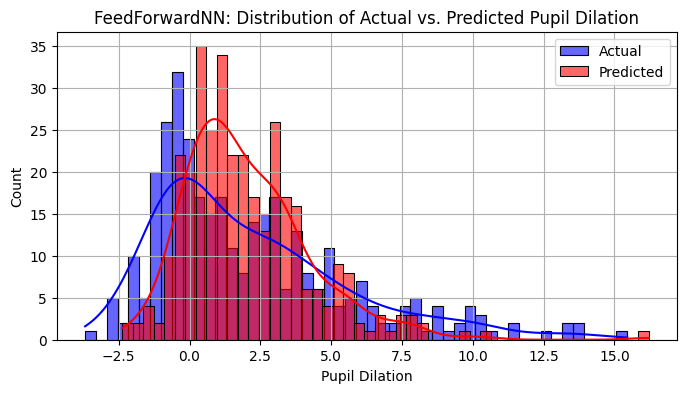

FeedForwardNN - Pearson Correlation: -0.0031


In [7]:
model_ff = train_feed_forward_nn(X_train, Y_train,epochs=2000)
evaluate_model(model_ff, X_test, Y_test, df_clean, scaler_Y=scaler_Y)

## LCNECortex Fitter Model

Now coming to our customized LCNECortex model

In [9]:
# model_lc_vanilla = train_vanilla_lc_model(X_train, Y_train, epochs=2000)
# evaluate_model(model_lc_vanilla, X_test, Y_test, df_clean, scaler_Y=scaler_Y)

## FF Gadget Model

Epoch 0, Loss: 0.031474


/Users/kevinb/miniforge3/envs/cse251b/lib/python3.9/site-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Epoch 100, Loss: 0.040398
Epoch 200, Loss: 0.025050
Epoch 300, Loss: 0.017744
Early stopping triggered at epoch 310
Training complete!
Evaluating Model: FFGadgetController


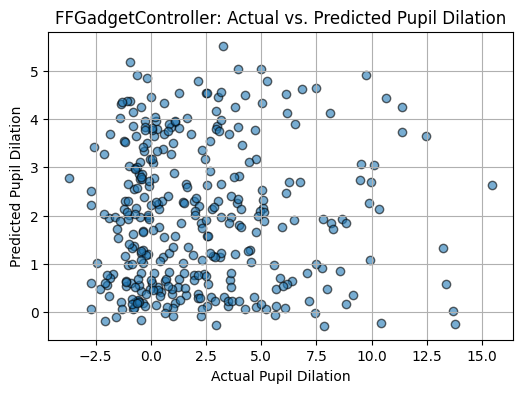

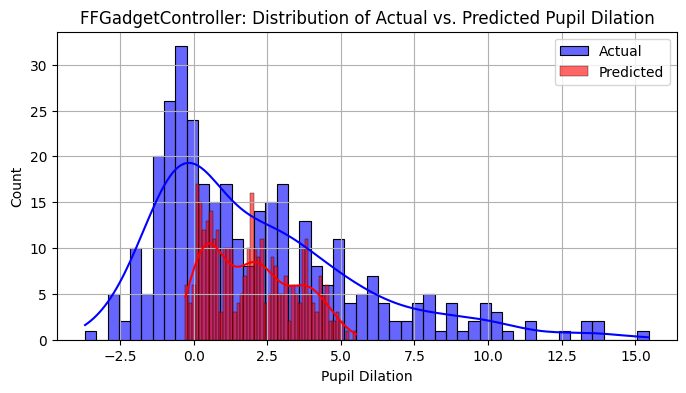

FFGadgetController - Pearson Correlation: 0.0170


In [10]:
ff_gadget = train_ff_controller(X_train, Y_train, epochs=5000, hidden_dim=124, patience=200)
evaluate_model(ff_gadget, X_test, Y_test, df_clean, scaler_Y=scaler_Y)

## Modified Uncertainty GadgetModel

We can adjust the uncertainty scale, which is deemed to be consisting of having certain randomness in the action (higher entropy, less loss, favoring more random actions)

Epoch 0, Loss: 0.951490


/Users/kevinb/miniforge3/envs/cse251b/lib/python3.9/site-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Epoch 100, Loss: 0.050306
Epoch 200, Loss: 0.052891
Epoch 300, Loss: 0.057531
Epoch 400, Loss: 0.049677
Epoch 500, Loss: 0.042739
Early stopping triggered at epoch 514
Training complete!


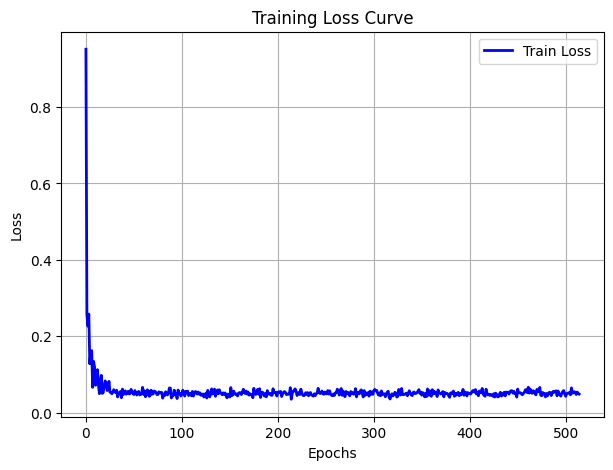

Evaluating Model: FFGadgetUncertainController
Adjusting prev_LC size: torch.Size([256, 256]) -> torch.Size([340, 256])


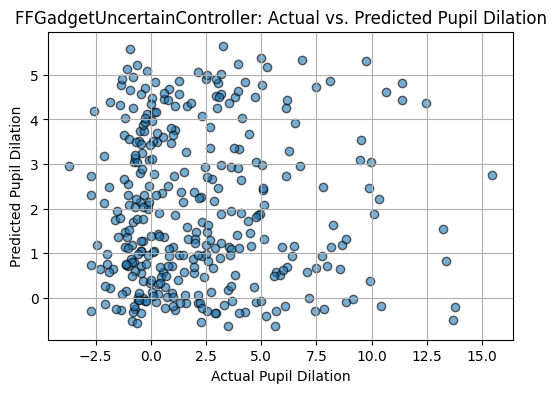

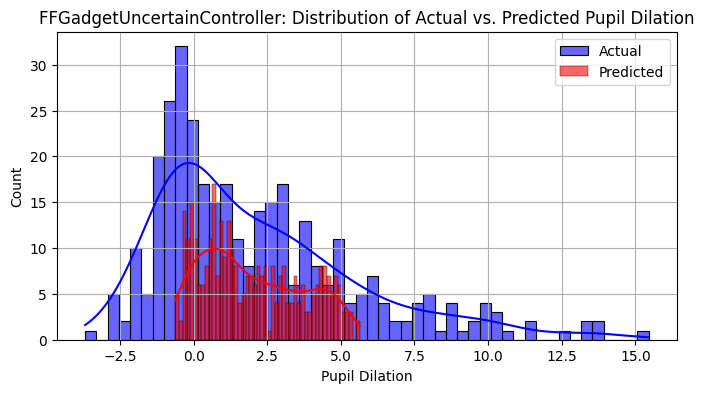

FFGadgetUncertainController - Pearson Correlation: 0.0144


In [11]:
# ff_uncertain_gadget = train_ff_uncertain_controller(X_tensor, Y_tensor, epochs=1000, hidden_dim=256, batch_size=256, patience=300)
ff_uncertain_gadget = train_ff_uncertain_controller(X_tensor, Y_tensor, epochs=1000, hidden_dim=256, batch_size=256, patience=300, entropy_scale=0.2)
evaluate_model(ff_uncertain_gadget, X_test, Y_test, df_clean, scaler_Y=scaler_Y)

# Analysis of the Networks

In [12]:
from analysis.analysis import (pca_lcne_lstm,
                               pca_feed_forward,
                               pca_lcne,
                               pca_lstm,
                               analyze_ff_gadget_activations,
                               evaluate_ff_uncertainty_gadget
)

/Users/kevinb/miniforge3/envs/cse251b/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Feed-Forward Neural Networks

In [13]:
# pca_feed_forward(model_ff, X_tensor, df_behavior)

## LCNECortex Model

We will see that, though  under fitted with the real data, there are some structureness to the data that we can play around with since we injected mechanistic insights into it.

In [15]:
# pca_lcne(model_lc_vanilla, X_tensor, df_clean)

## Feed-Forward Neural Gadget Controller

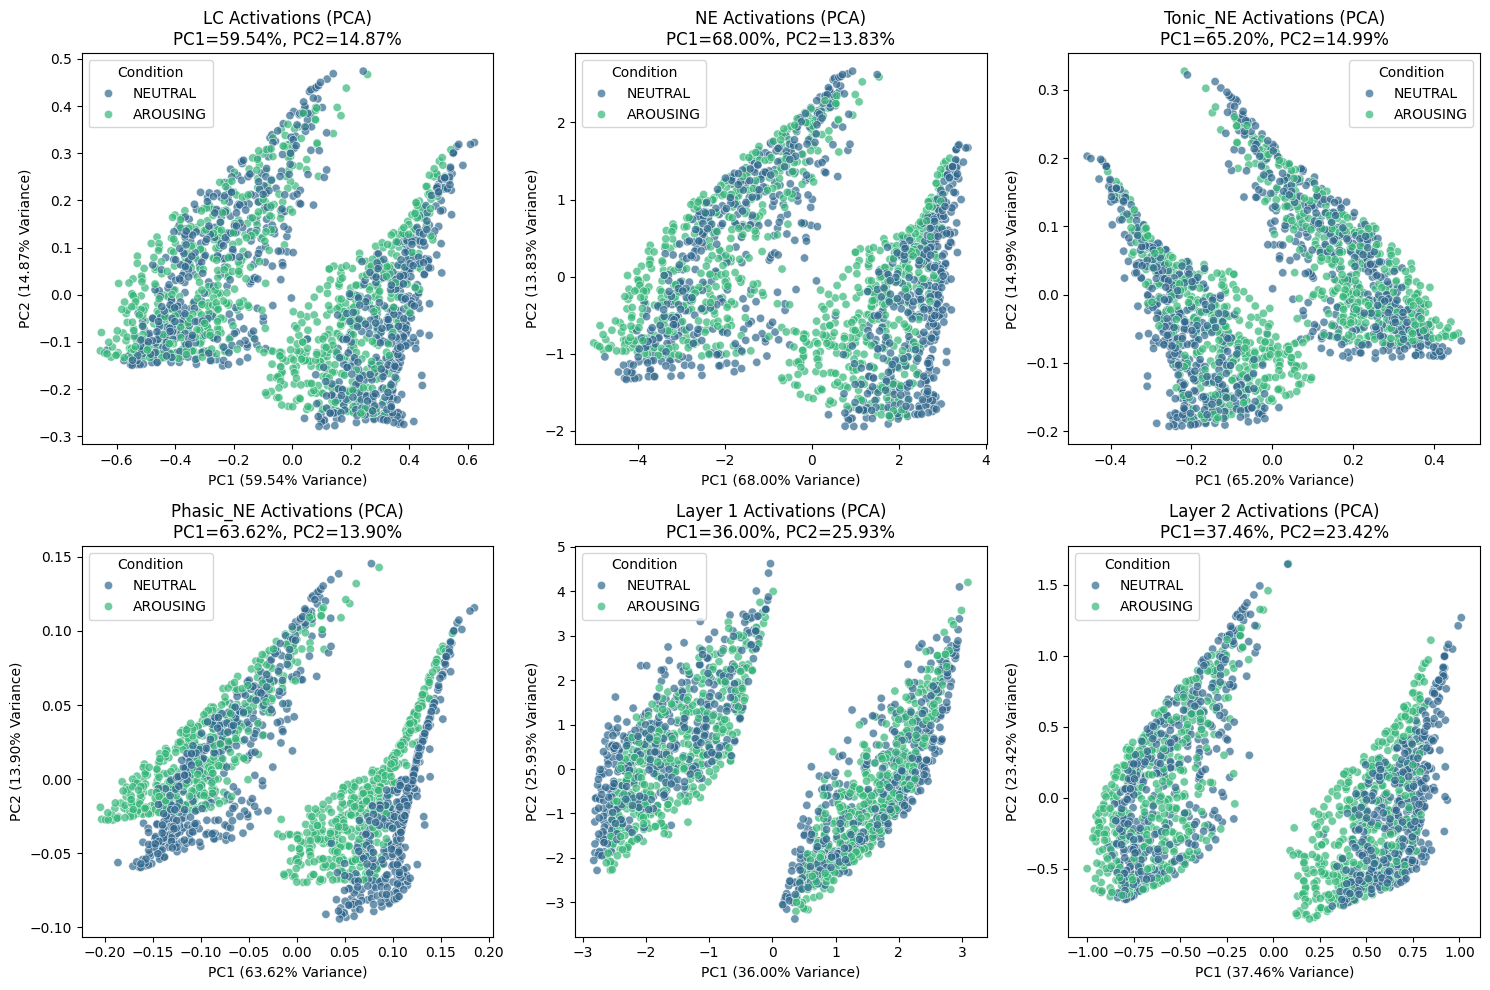

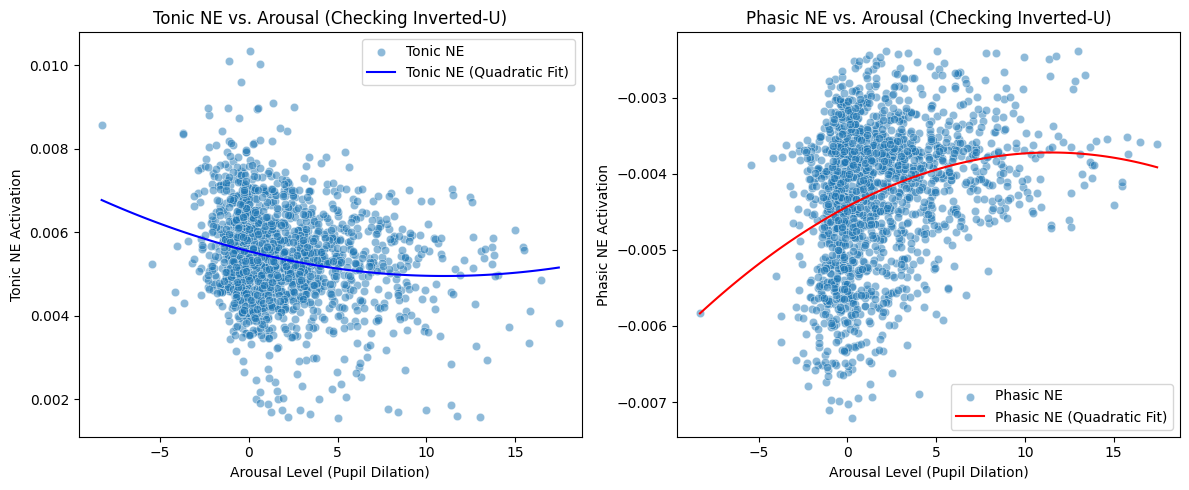


 Pearson Correlation with Actual Pupil Dilation:
LC: -0.361
NE: 0.400
Tonic_NE: -0.189
Phasic_NE: 0.285
Layer 1: -0.230
Layer 2: -0.064
Predicted Pupil Dilation: 0.454


In [18]:
analyze_ff_gadget_activations(ff_gadget, X_tensor, df_clean)

This model elarning representation is quite unstable

## Feed-Forward Neural Gadget Uncertainty Controller

Adjusting prev_LC size: torch.Size([340, 256]) -> torch.Size([1699, 256])
Pupil Dilation MAE: 2.1893
Pupil Dilation MSE: 8.3849


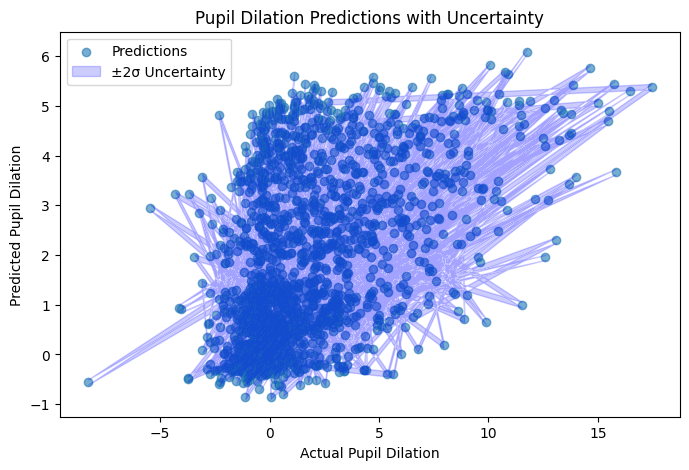

In [19]:
evaluate_ff_uncertainty_gadget(ff_uncertain_gadget, X_tensor, Y_tensor, scaler_Y)

# Maniforlds Projections Nalaysis for Feed-Forward Neural Gadget Uncertainty Controller

In [20]:
from analysis.analysis import (extract_activations_gadget,
                               compute_mapper_graph,
                               compute_persistent_homology,
                               compute_persistent_homology_overlay,
                               compute_mapper_graph_overlay,
                               plot_manifold_projection,
                               construct_activation_graph,
                               plot_activation_graph)

Adjusting prev_LC size: torch.Size([1699, 256]) -> torch.Size([170, 256])
Adjusting prev_LC size: torch.Size([170, 256]) -> torch.Size([171, 256])


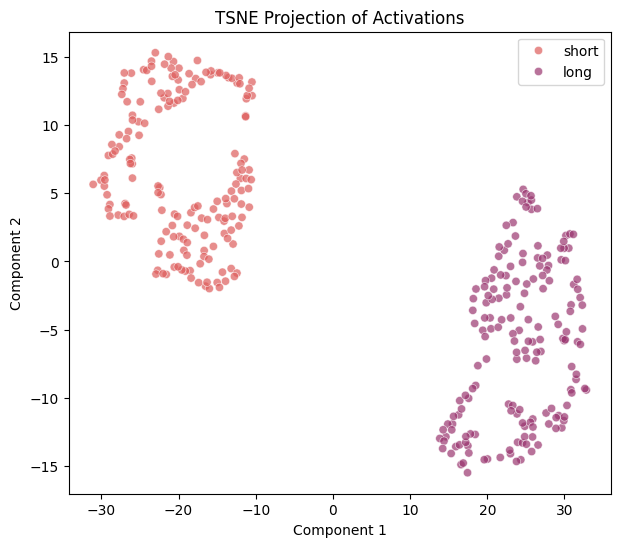

/Users/kevinb/miniforge3/envs/cse251b/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/kevinb/miniforge3/envs/cse251b/lib/python3.9/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


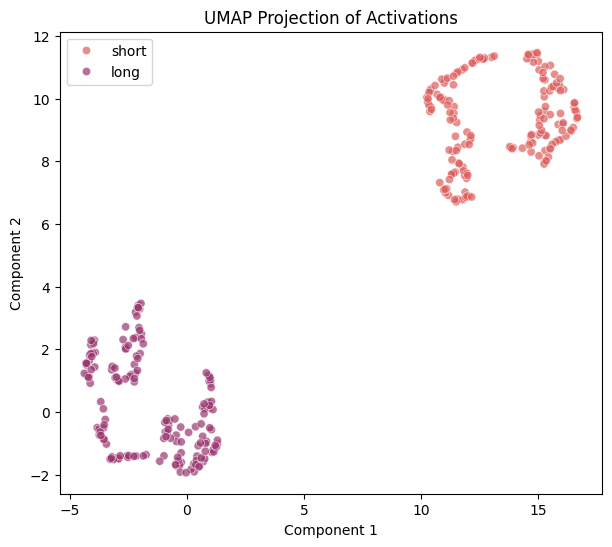

In [21]:
activations_short = extract_activations_gadget(ff_uncertain_gadget, X_short_test)
activations_long = extract_activations_gadget(ff_uncertain_gadget, X_long_test)

all_activations = np.vstack([activations_short["LC"], activations_long["LC"]])
labels = np.array(["short"] * len(activations_short["LC"]) + ["long"] * len(activations_long["LC"]))

# t-SNE projection
plot_manifold_projection(all_activations, labels, method="tsne")

# UMAP projection
plot_manifold_projection(all_activations, labels, method="umap")

## Cosine Similarity Graph

We create an `cosine similarity` graph by connecting similar components in the vector space accoridng to certain similarity threshold.

Adjusting prev_LC size: torch.Size([171, 256]) -> torch.Size([848, 256])
Adjusting prev_LC size: torch.Size([848, 256]) -> torch.Size([851, 256])


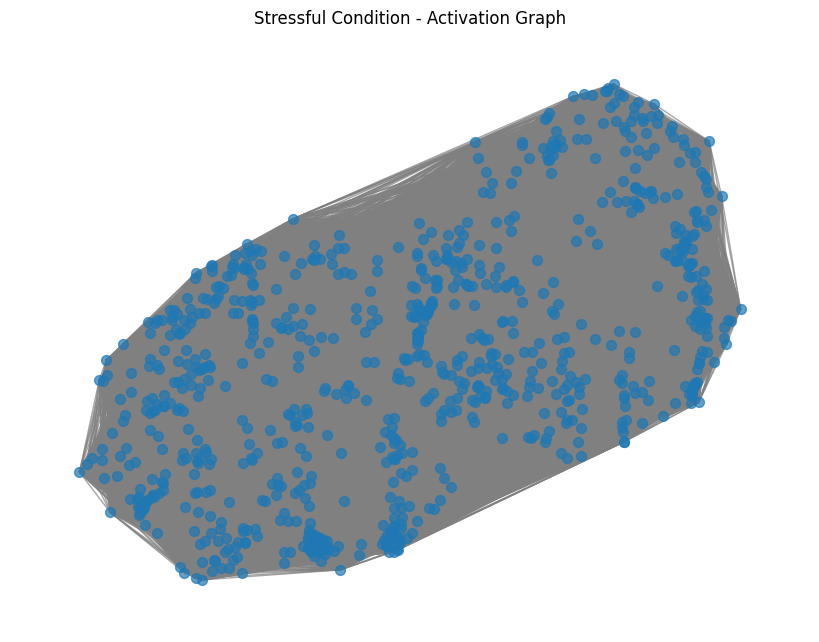

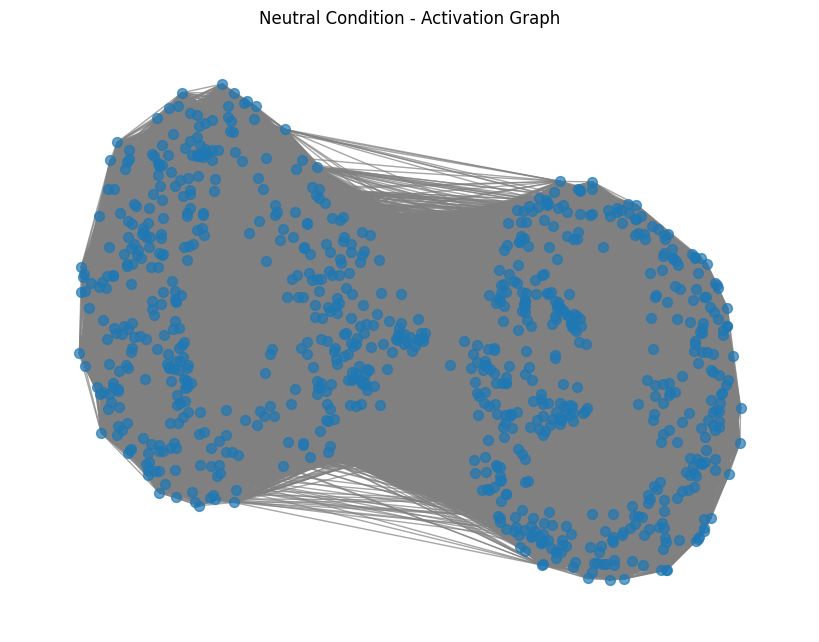

In [22]:
activations_stress = extract_activations_gadget(ff_uncertain_gadget, X_stress)
activations_neutral = extract_activations_gadget(ff_uncertain_gadget, X_neurtal)

G_stress = construct_activation_graph(activations_stress["LC"], threshold=0.91)
G_neutral = construct_activation_graph(activations_neutral["LC"], threshold=0.91)

plot_activation_graph(G_stress, title="Stressful Condition - Activation Graph")
plot_activation_graph(G_neutral, title="Neutral Condition - Activation Graph")

## Homology Analyiss
Conducting a persistent homology analysis, which seems to work with the `uncertainty` control model but not other models.

- Formation o higher dimension cyclic loops definately exist

Adjusting prev_LC size: torch.Size([340, 256]) -> torch.Size([1699, 256])
Analyzing LC activations...


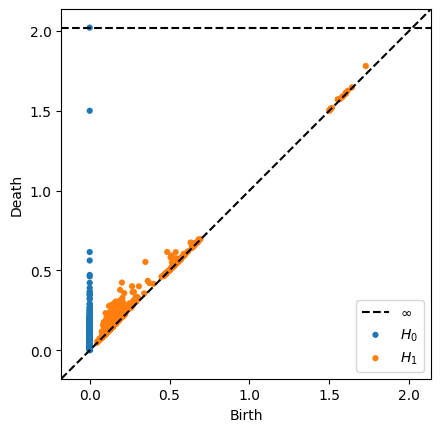

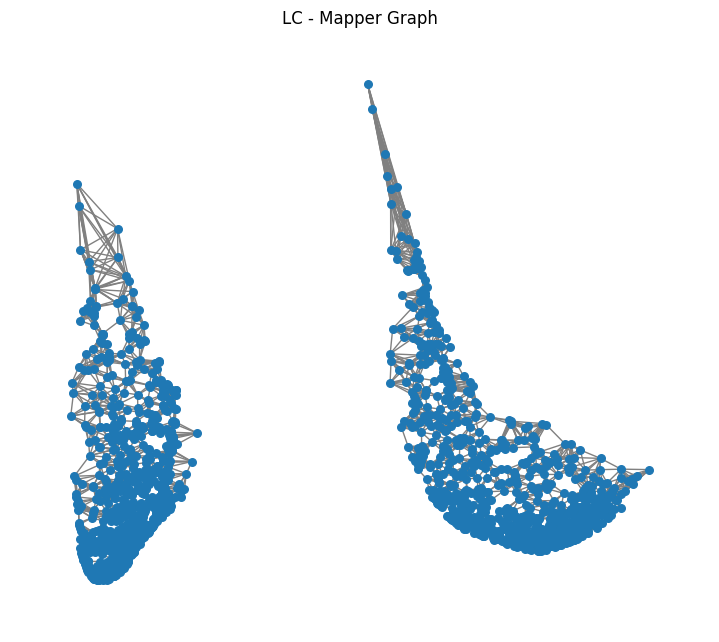

Analyzing NE activations...


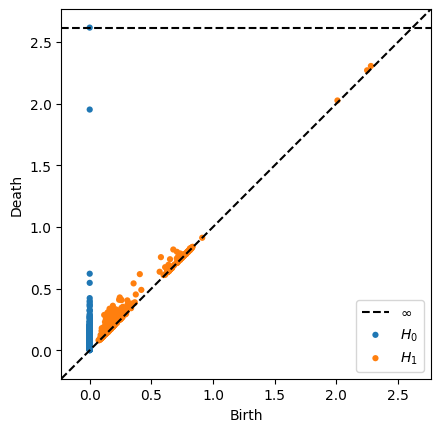

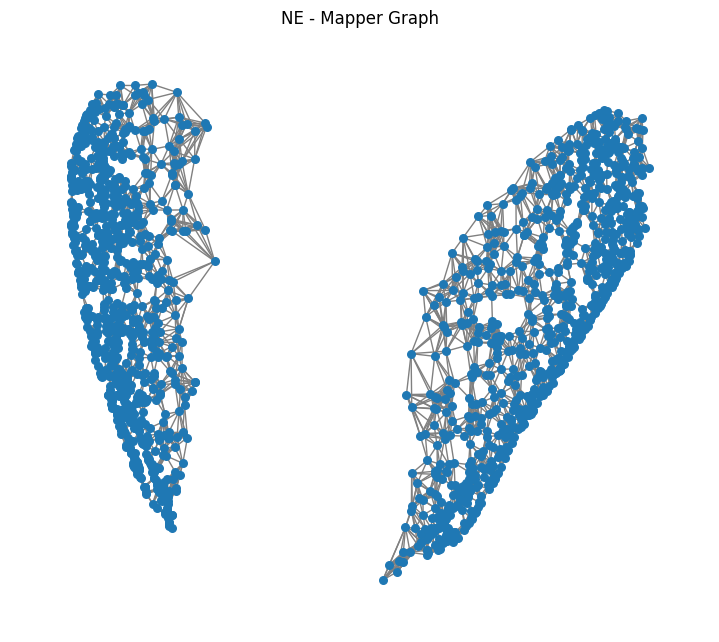

Analyzing Tonic_NE activations...


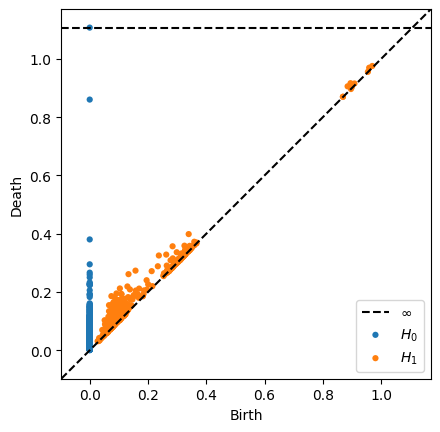

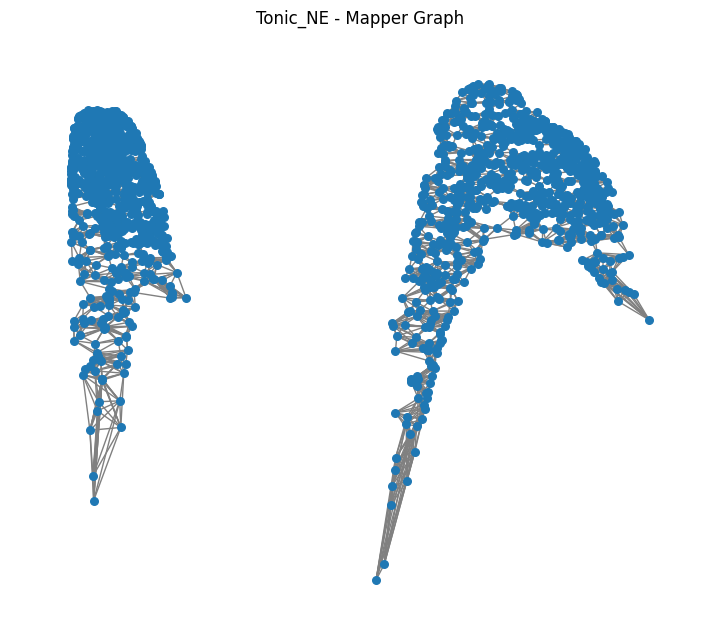

Analyzing Phasic_NE activations...


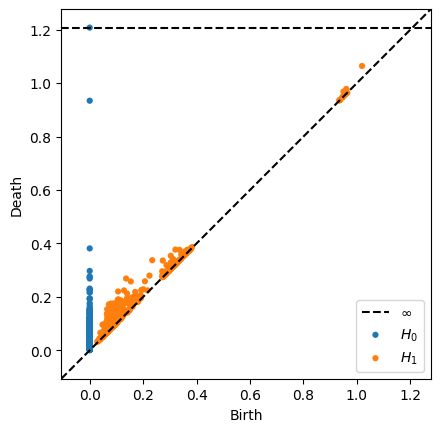

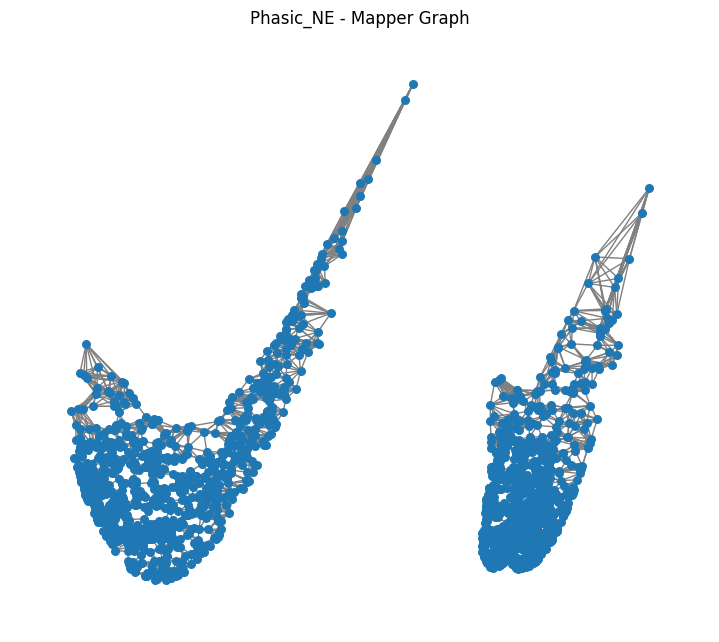

Analyzing Hidden_1 activations...


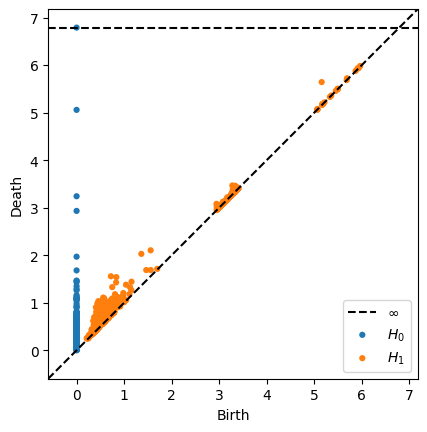

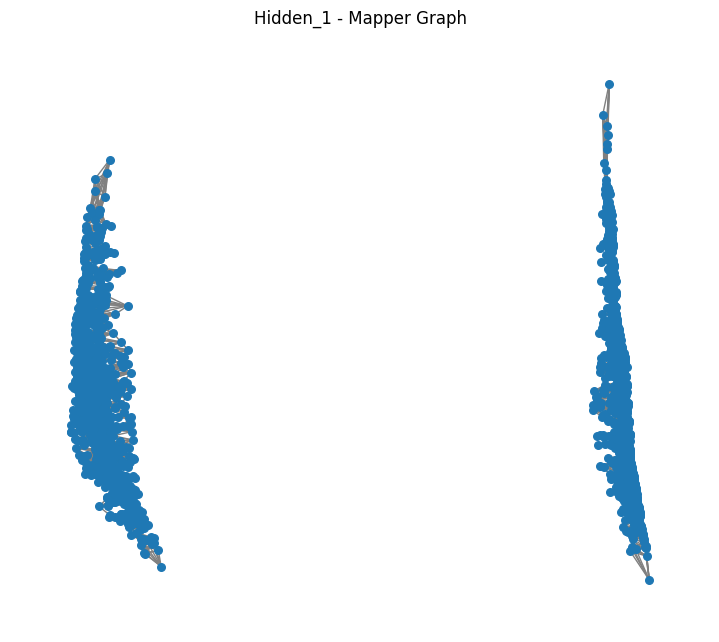

Analyzing Hidden_2 activations...


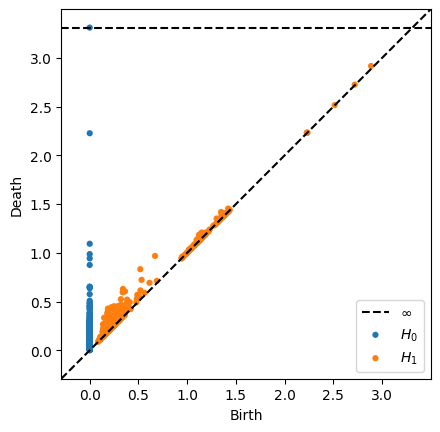

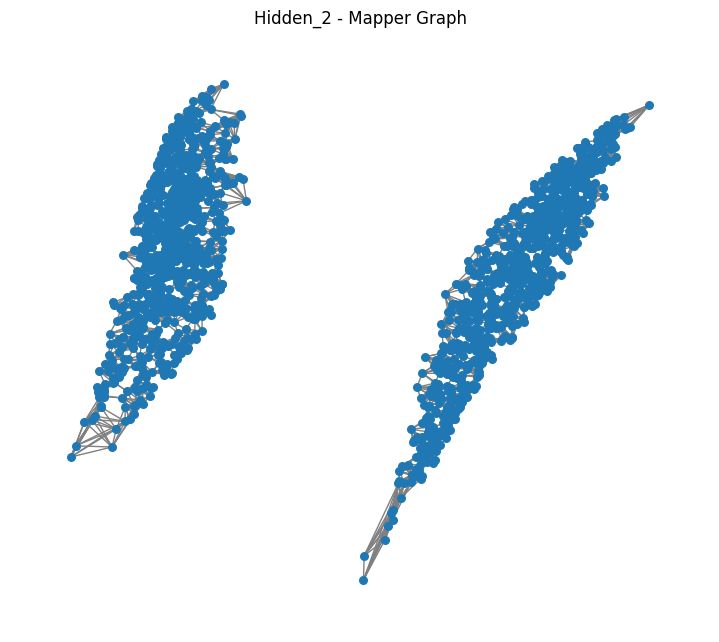

In [30]:
activations = extract_activations_gadget(ff_uncertain_gadget, X_tensor)
# activations = extract_activations_ff_uncertain_gadget(ff_gadget, X_tensor)

for key, act in activations.items():
    print(f"Analyzing {key} activations...")
    compute_persistent_homology(act, title=f"{key} - Persistent Homology")
    compute_mapper_graph(act, title=f"{key} - Mapper Graph")

## Seperated Homology Analysis

1. Loops persisting longer in `longer_duration_trials` suggest sustained neural activity patterns, possibly indicating difficulty in switching away from stress-induced cognitive states.

2. More spread out birth time of these high dimensional cyclic components

3. If using all of the data (stress/non_stress), the spread is more obvious.
    - Higher variance in stressful trials means more variation in cyclic patterns.
    - If LC-NE responses fluctuate more under stress, the model fails to stabilize activations, increasing variance. Phasic NE bursts might cause chaotic transitions rather than smooth changes.

Adjusting prev_LC size: torch.Size([1699, 256]) -> torch.Size([171, 256])
Adjusting prev_LC size: torch.Size([171, 256]) -> torch.Size([170, 256])
Analyzing LC activations...


/Users/kevinb/miniforge3/envs/cse251b/lib/python3.9/site-packages/ripser/ripser.py:253: UserWarning: The input point cloud has more columns than rows; did you mean to transpose?
  warnings.warn(
/Users/kevinb/miniforge3/envs/cse251b/lib/python3.9/site-packages/ripser/ripser.py:253: UserWarning: The input point cloud has more columns than rows; did you mean to transpose?
  warnings.warn(


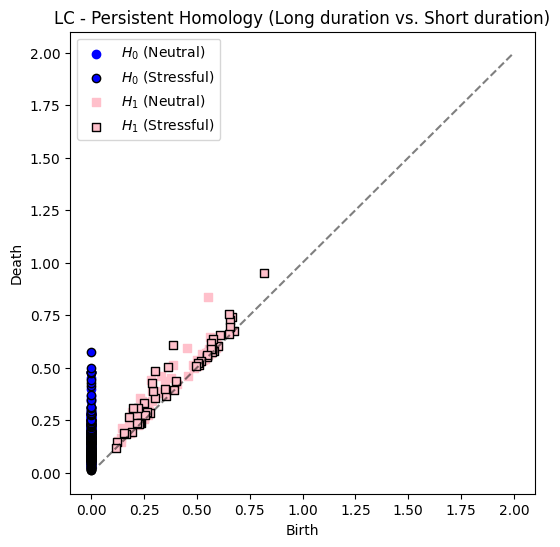

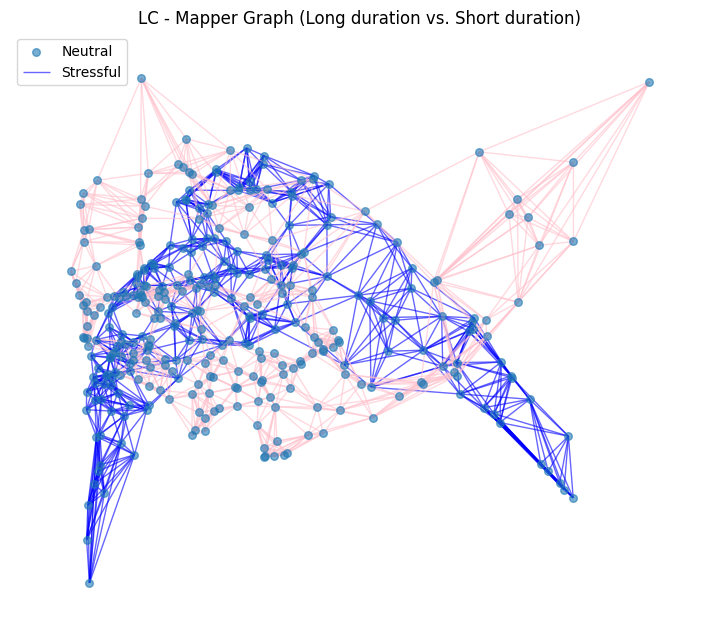

Analyzing NE activations...


/Users/kevinb/miniforge3/envs/cse251b/lib/python3.9/site-packages/ripser/ripser.py:253: UserWarning: The input point cloud has more columns than rows; did you mean to transpose?
  warnings.warn(
/Users/kevinb/miniforge3/envs/cse251b/lib/python3.9/site-packages/ripser/ripser.py:253: UserWarning: The input point cloud has more columns than rows; did you mean to transpose?
  warnings.warn(


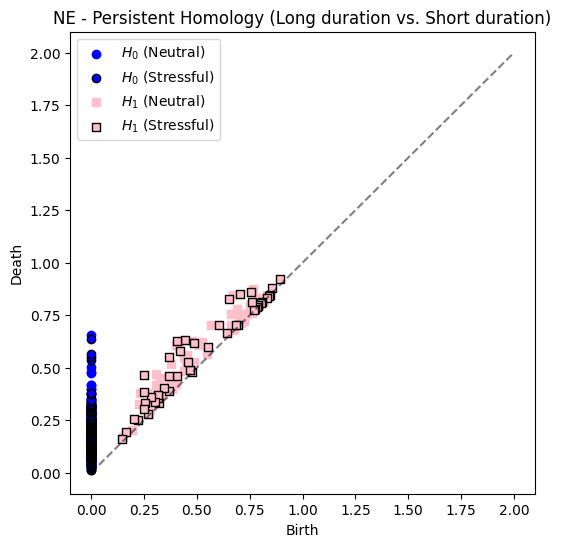

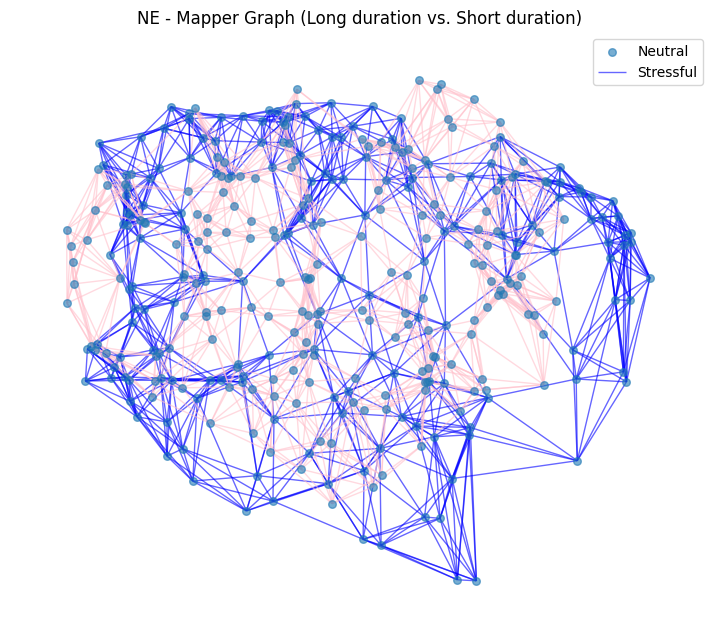

Analyzing Tonic_NE activations...


/Users/kevinb/miniforge3/envs/cse251b/lib/python3.9/site-packages/ripser/ripser.py:253: UserWarning: The input point cloud has more columns than rows; did you mean to transpose?
  warnings.warn(
/Users/kevinb/miniforge3/envs/cse251b/lib/python3.9/site-packages/ripser/ripser.py:253: UserWarning: The input point cloud has more columns than rows; did you mean to transpose?
  warnings.warn(


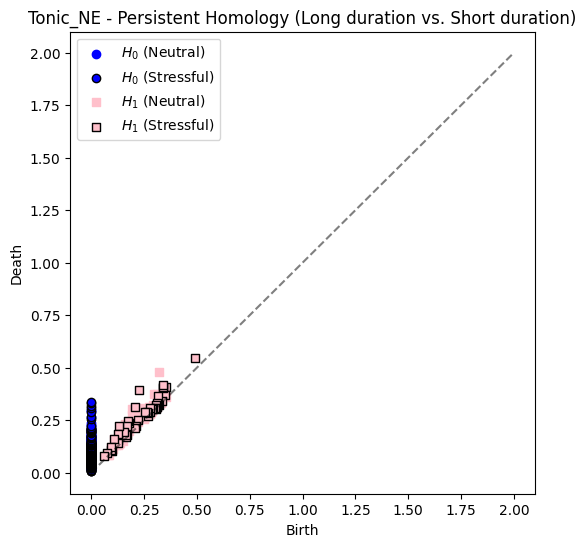

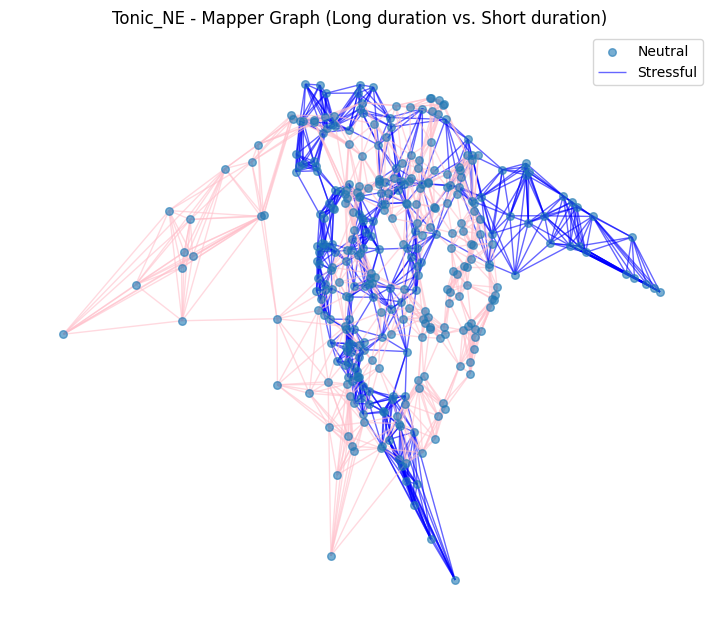

Analyzing Phasic_NE activations...


/Users/kevinb/miniforge3/envs/cse251b/lib/python3.9/site-packages/ripser/ripser.py:253: UserWarning: The input point cloud has more columns than rows; did you mean to transpose?
  warnings.warn(
/Users/kevinb/miniforge3/envs/cse251b/lib/python3.9/site-packages/ripser/ripser.py:253: UserWarning: The input point cloud has more columns than rows; did you mean to transpose?
  warnings.warn(


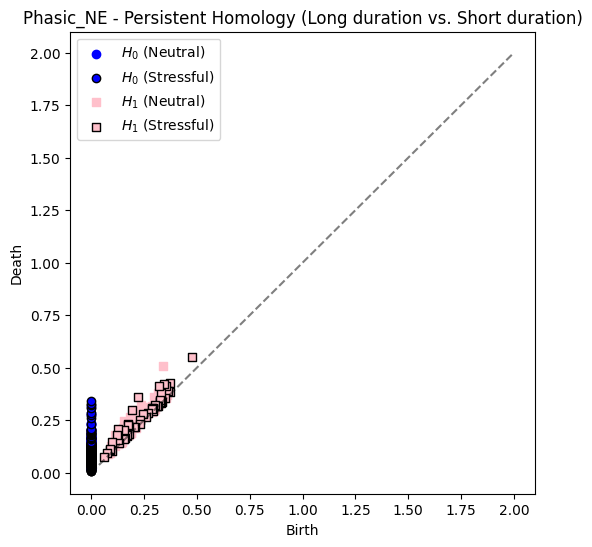

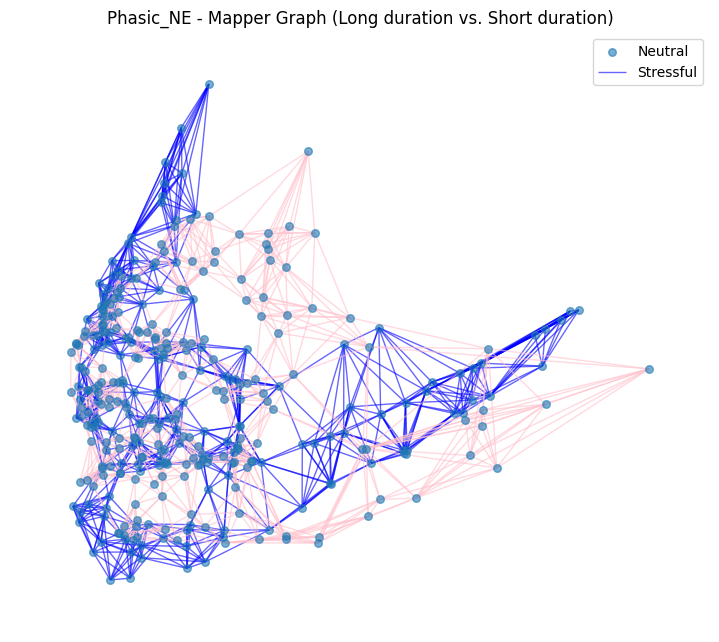

Analyzing Hidden_1 activations...


/Users/kevinb/miniforge3/envs/cse251b/lib/python3.9/site-packages/ripser/ripser.py:253: UserWarning: The input point cloud has more columns than rows; did you mean to transpose?
  warnings.warn(
/Users/kevinb/miniforge3/envs/cse251b/lib/python3.9/site-packages/ripser/ripser.py:253: UserWarning: The input point cloud has more columns than rows; did you mean to transpose?
  warnings.warn(


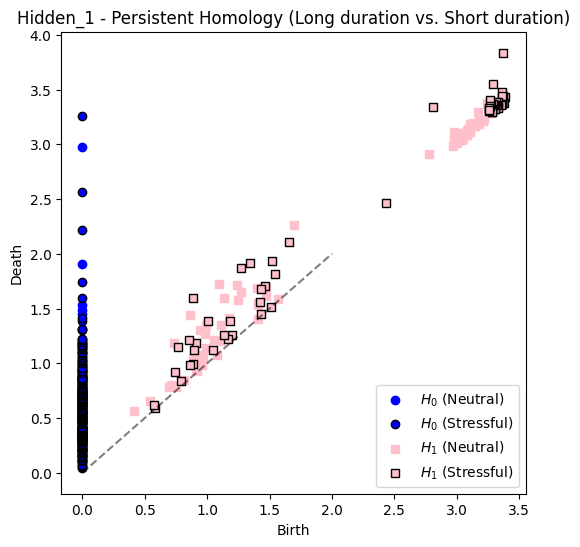

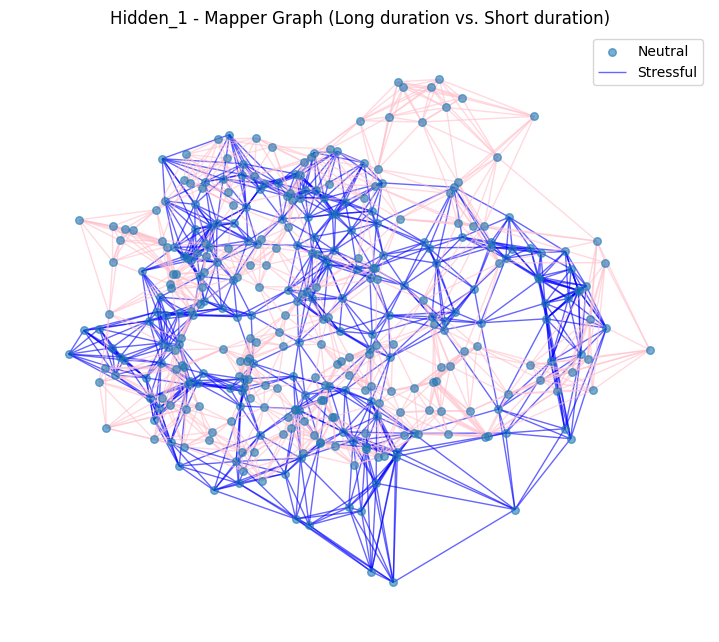

Analyzing Hidden_2 activations...


/Users/kevinb/miniforge3/envs/cse251b/lib/python3.9/site-packages/ripser/ripser.py:253: UserWarning: The input point cloud has more columns than rows; did you mean to transpose?
  warnings.warn(
/Users/kevinb/miniforge3/envs/cse251b/lib/python3.9/site-packages/ripser/ripser.py:253: UserWarning: The input point cloud has more columns than rows; did you mean to transpose?
  warnings.warn(


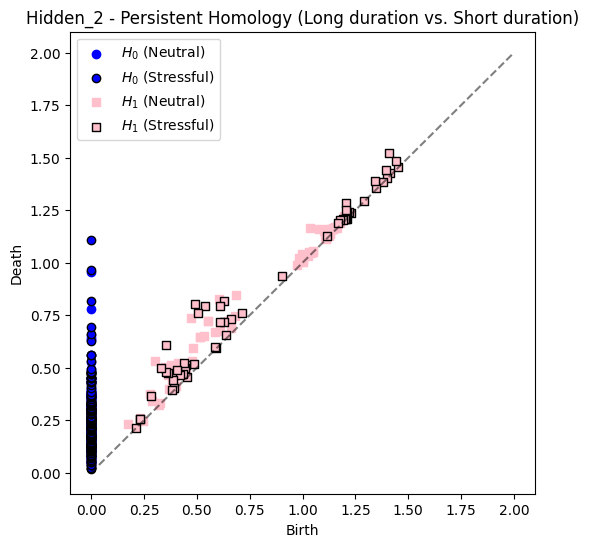

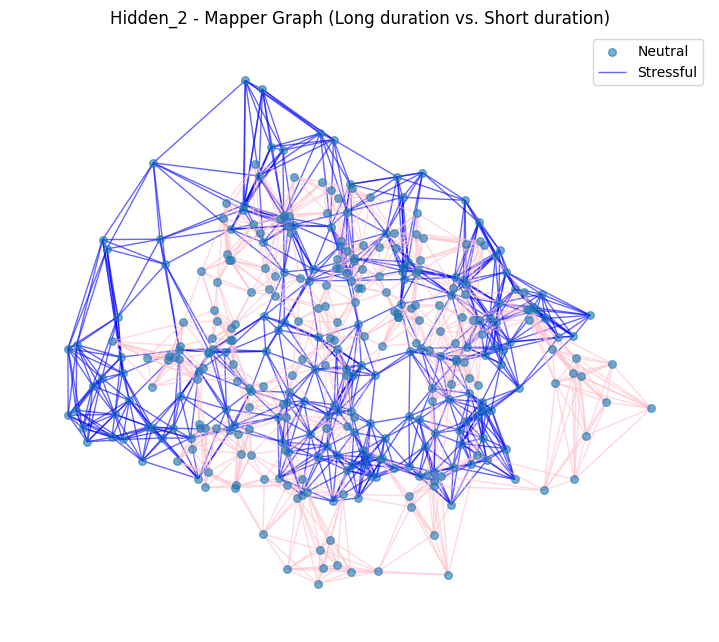

In [24]:
activations_long = extract_activations_gadget(ff_uncertain_gadget, X_long_test)
activations_short = extract_activations_gadget(ff_uncertain_gadget, X_short_test)

for key in activations_long.keys():
    print(f"Analyzing {key} activations...")

    act_long = activations_long[key]
    act_short = activations_short[key]

    compute_persistent_homology_overlay(act_long, act_short, title=f"{key} - Persistent Homology (Long duration vs. Short duration)")
    compute_mapper_graph_overlay(act_long, act_short, title=f"{key} - Mapper Graph (Long duration vs. Short duration)")

Adjusting prev_LC size: torch.Size([170, 256]) -> torch.Size([851, 256])
Adjusting prev_LC size: torch.Size([851, 256]) -> torch.Size([848, 256])
Analyzing LC activations...


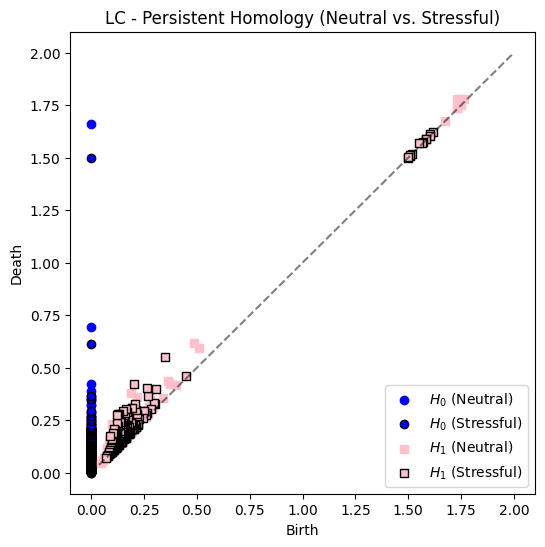

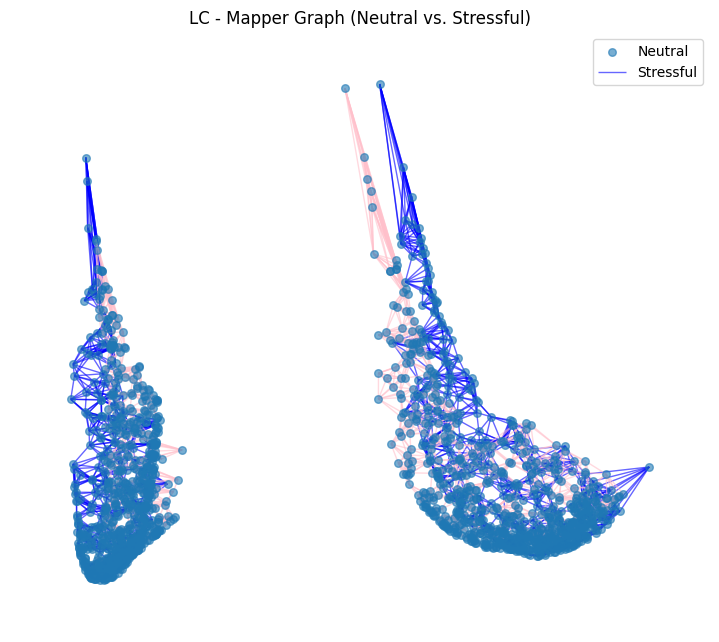

Analyzing NE activations...


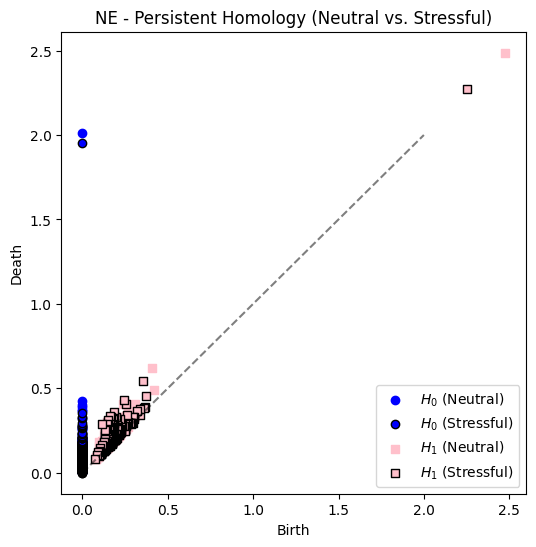

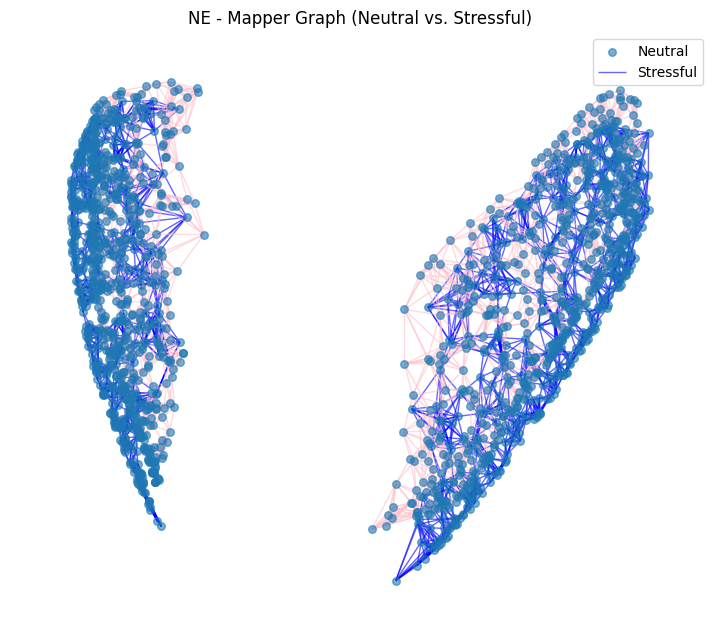

Analyzing Tonic_NE activations...


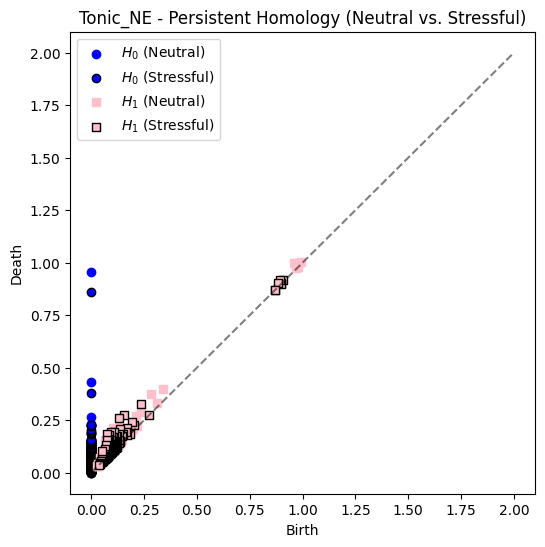

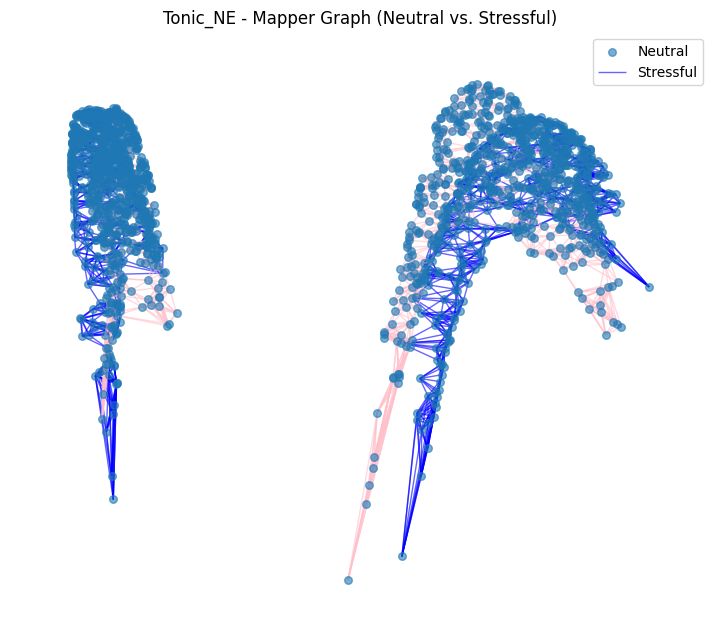

Analyzing Phasic_NE activations...


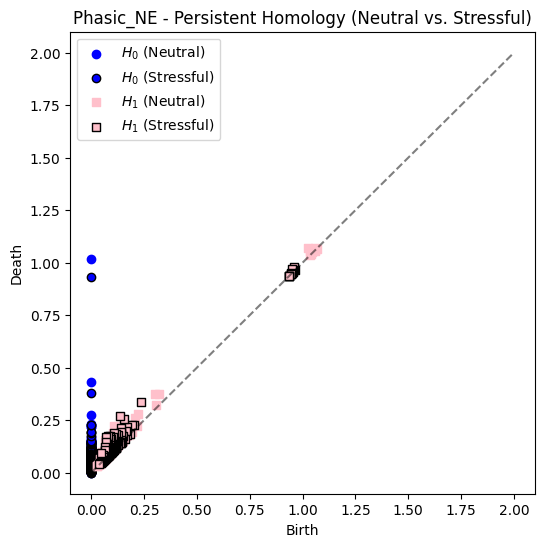

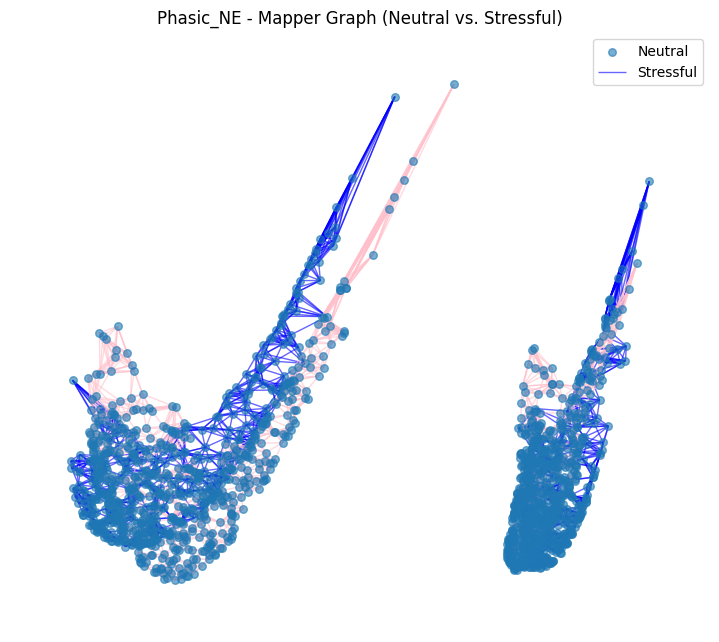

Analyzing Hidden_1 activations...


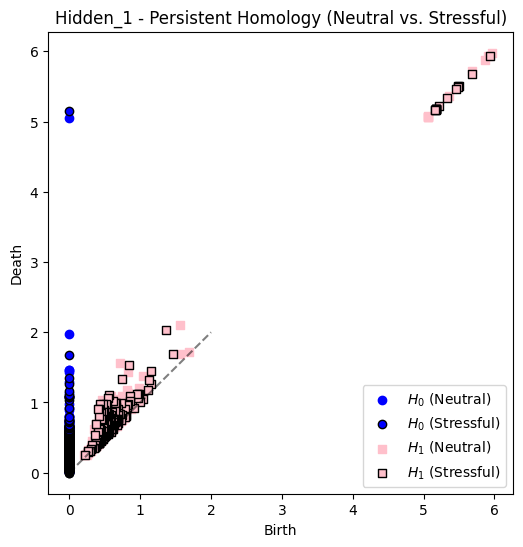

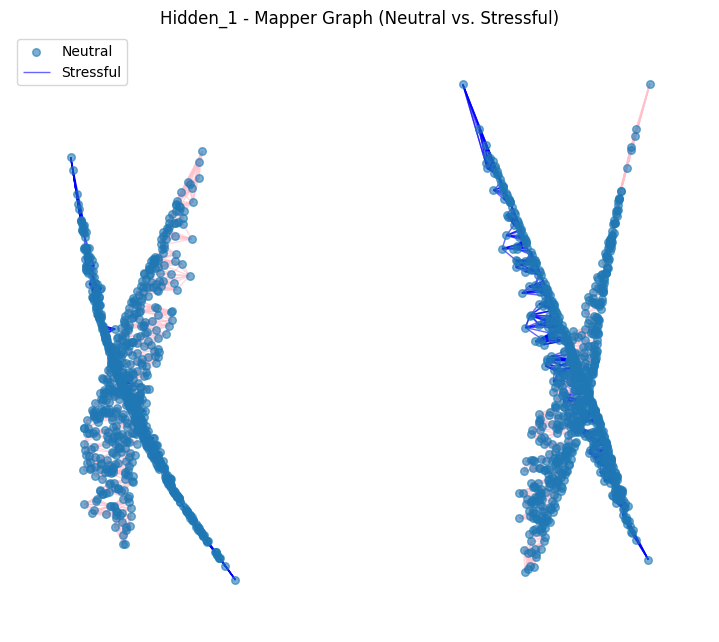

Analyzing Hidden_2 activations...


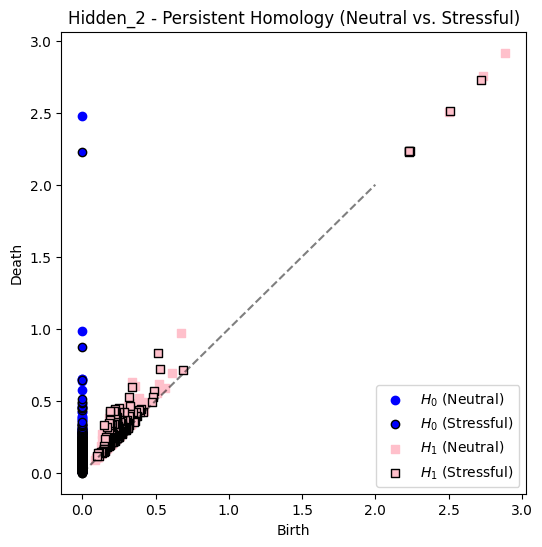

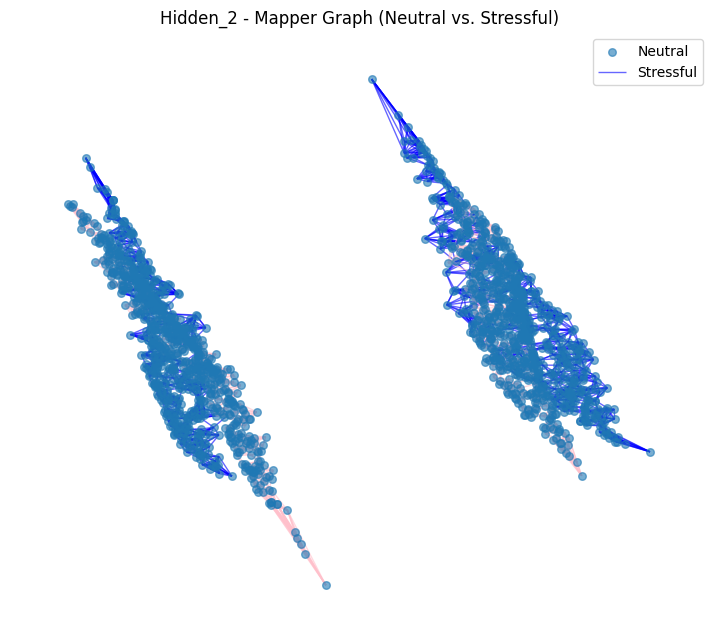

In [25]:
activations_neutral = extract_activations_gadget(ff_uncertain_gadget, X_neurtal)
activations_stress = extract_activations_gadget(ff_uncertain_gadget, X_stress)

for key in activations_neutral.keys():
    print(f"Analyzing {key} activations...")

    act_neutral = activations_neutral[key]
    act_stress = activations_stress[key]

    compute_persistent_homology_overlay(act_neutral, act_stress, title=f"{key} - Persistent Homology (Neutral vs. Stressful)")

    compute_mapper_graph_overlay(act_neutral, act_stress, title=f"{key} - Mapper Graph (Neutral vs. Stressful)")

# Experiments Setting Modification

In [26]:
from analysis.analysis import (analyze_uncertainty_relationships,
                               simulate_lc_activation)

Adjusting prev_LC size: torch.Size([848, 256]) -> torch.Size([1699, 256])


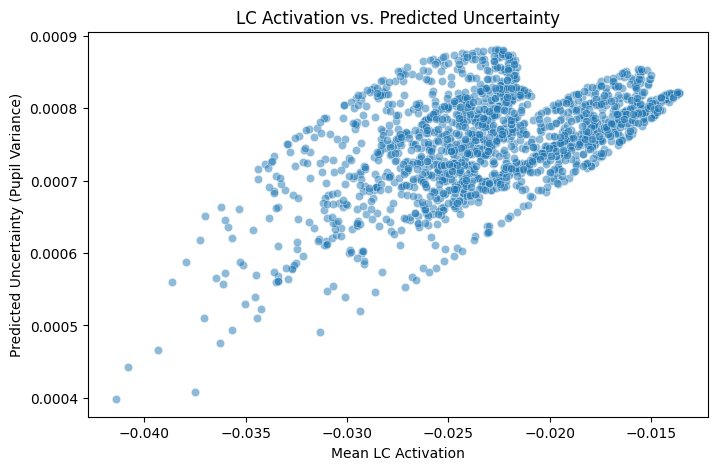

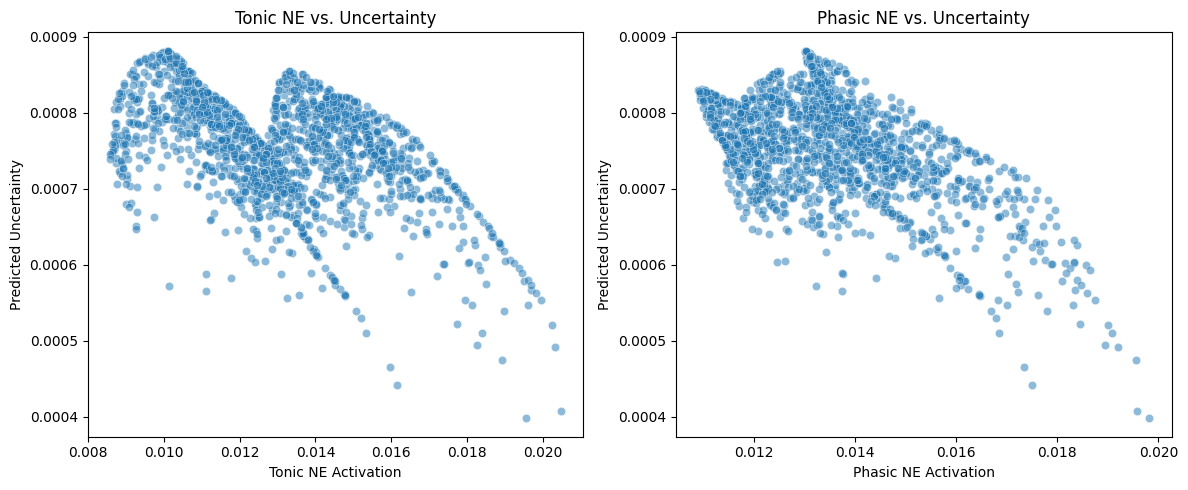


📊 **Correlation Results:**
LC vs. Uncertainty: 0.5233
Tonic NE vs. Uncertainty: -0.4943
Phasic NE vs. Uncertainty: -0.5500
NE vs. Uncertainty: 0.1734


In [27]:
uncertainty_results = analyze_uncertainty_relationships(ff_uncertain_gadget, X_tensor)

Adjusting prev_LC size: torch.Size([1699, 256]) -> torch.Size([340, 256])


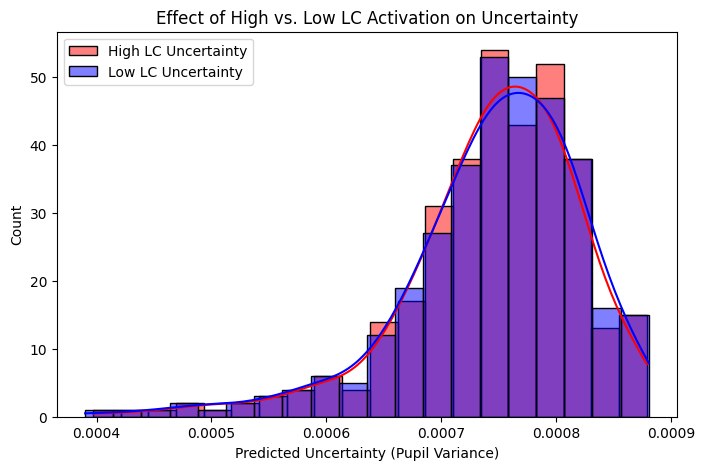

In [28]:
pupil_high, var_high, pupil_low, var_low = simulate_lc_activation(ff_uncertain_gadget, X_test, lc_boost=0.01)
plt.figure(figsize=(8,5))
sns.histplot(var_high.squeeze(), color="red", label="High LC Uncertainty", kde=True)
sns.histplot(var_low.squeeze(), color="blue", label="Low LC Uncertainty", kde=True)
plt.xlabel("Predicted Uncertainty (Pupil Variance)")
plt.title("Effect of High vs. Low LC Activation on Uncertainty")
plt.legend()
plt.show()

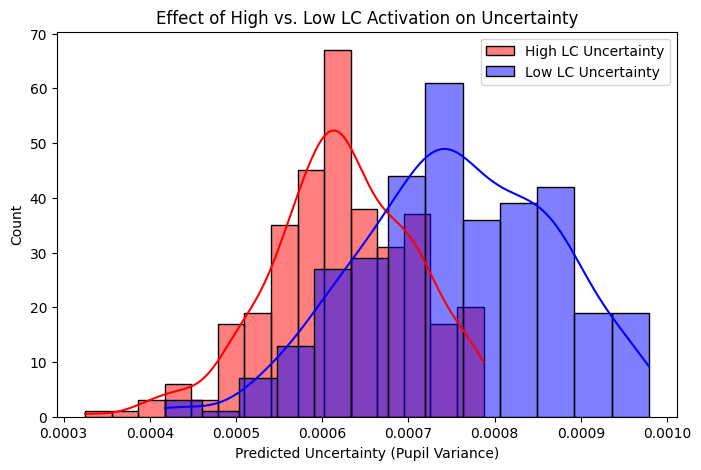

In [29]:
pupil_high, var_high, pupil_low, var_low = simulate_lc_activation(ff_uncertain_gadget, X_test, lc_boost=0.5)
plt.figure(figsize=(8,5))
sns.histplot(var_high.squeeze(), color="red", label="High LC Uncertainty", kde=True)
sns.histplot(var_low.squeeze(), color="blue", label="Low LC Uncertainty", kde=True)
plt.xlabel("Predicted Uncertainty (Pupil Variance)")
plt.title("Effect of High vs. Low LC Activation on Uncertainty")
plt.legend()
plt.show()